In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [2]:
df = pd.read_csv("Data/claims_train.csv")
df = df[df["Exposure"] <= 1]
df["target"] = df["ClaimNb"]/df["Exposure"]
df['target'] = (df['target'] > 0).astype(int)
df = df.drop(columns = "IDpol")
df

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,target
0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24,0
1,0,0.10,D,7,17,80,95,B2,Regular,598,R25,0
2,0,0.33,E,7,3,36,76,B6,Regular,4172,R82,0
3,0,0.56,A,5,4,73,52,B13,Diesel,15,R24,0
4,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53,0
...,...,...,...,...,...,...,...,...,...,...,...,...
542405,0,0.20,D,6,10,32,76,B2,Diesel,1314,R24,0
542406,0,0.06,D,10,14,34,60,B5,Diesel,685,R72,0
542407,0,0.34,C,6,8,32,95,B5,Diesel,242,R82,0
542408,0,0.72,E,9,7,39,72,B2,Regular,3301,R73,0


## Seperation

In [3]:

# Separating columns
catg_cols = df.select_dtypes(include=['object']) 
numerical = df.select_dtypes(include=['float64', 'int64'])

#data with numerical 
numerical = numerical.drop(columns= "target")
display(numerical)

#data with categorical One-Hot - encoded 
df_encoded = pd.get_dummies(catg_cols, dtype=int, drop_first = False)
display(df_encoded)


,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
0,0,0.43,7,18,36,95,1054
1,0,0.10,7,17,80,95,598
2,0,0.33,7,3,36,76,4172
3,0,0.56,5,4,73,52,15
4,0,0.27,8,0,37,50,3021
...,...,...,...,...,...,...,...
542405,0,0.20,6,10,32,76,1314
542406,0,0.06,10,14,34,60,685
542407,0,0.34,6,8,32,95,242
542408,0,0.72,9,7,39,72,3301


,Area_A,Area_B,Area_C,Area_D,Area_E,Area_F,VehBrand_B1,VehBrand_B10,VehBrand_B11,VehBrand_B12,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542405,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
542406,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
542407,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
542408,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


### PCA Computation

In [4]:
# Standardizing all features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numerical)

# Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(data_scaled)
principal_components

#creating a new dataframe for the PCA components
n_components = pca.n_components_  
pca_column_names = [f'pca_{i+1}' for i in range(n_components)]
PC = pd.DataFrame(principal_components,columns = pca_column_names)

#resetting the index
PC = PC.reset_index(drop=True)
df_encoded = df_encoded.reset_index(drop = True)


#Merging the two datas. 
df1 = pd.concat([PC,df_encoded],axis= 1)
df1

,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,Area_A,Area_B,Area_C,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,2.028891,1.540115,-0.517281,1.050724,0.370283,-0.598621,1.069810,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.369768,0.565512,-0.579261,0.659968,0.230879,-2.195564,3.100568,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.341667,-0.843856,0.030775,0.051334,0.120743,0.441316,0.298189,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,-1.619575,-0.283476,-0.039853,-1.090552,-0.064959,-0.436851,0.994988,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.181917,-1.534528,-0.265681,0.099391,-0.508453,0.485538,-0.744411,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541411,1.649722,0.303388,-0.424759,-0.040975,-0.091983,-0.425516,0.031658,0,0,0,...,0,0,0,0,0,0,0,0,0,0
541412,0.897734,-0.106677,-1.170627,1.797638,-0.706599,-0.877060,-0.509662,0,0,0,...,0,0,1,0,0,0,0,0,0,0
541413,2.250432,0.556368,-0.225081,-0.137730,-0.240797,0.207321,0.992973,0,0,1,...,0,0,0,0,0,1,0,0,0,0
541414,0.557021,-0.134735,-0.132380,1.235229,0.179047,0.891337,0.375607,0,0,0,...,0,0,0,1,0,0,0,0,0,0


### Visualisation 

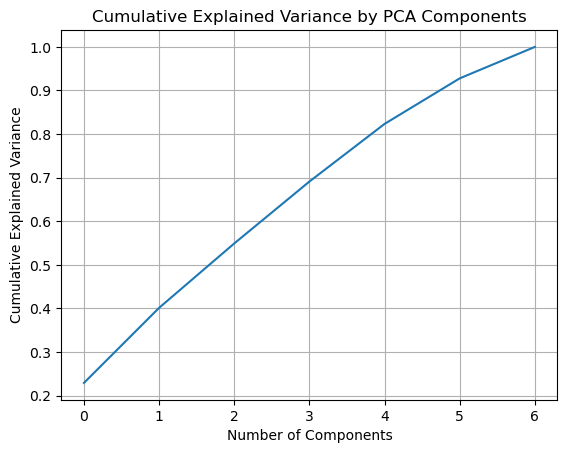

7


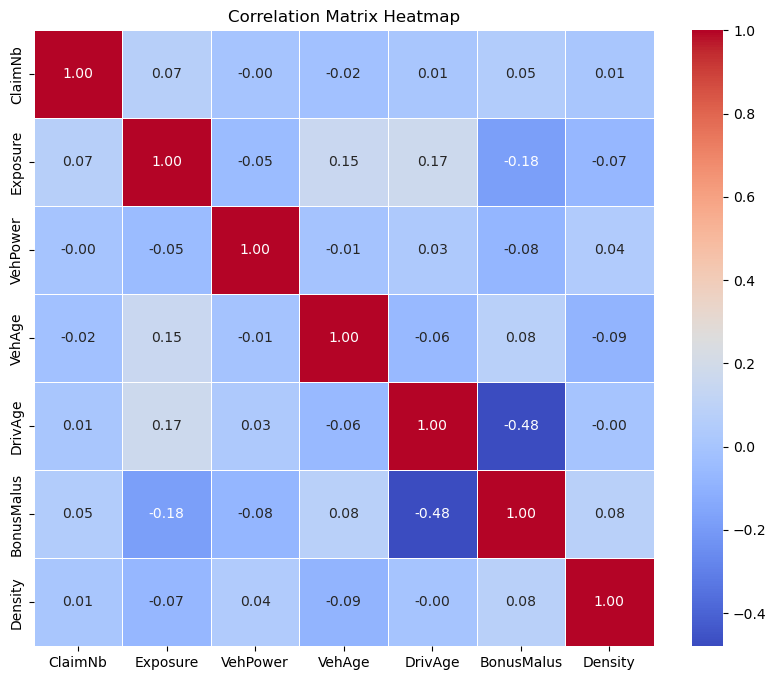

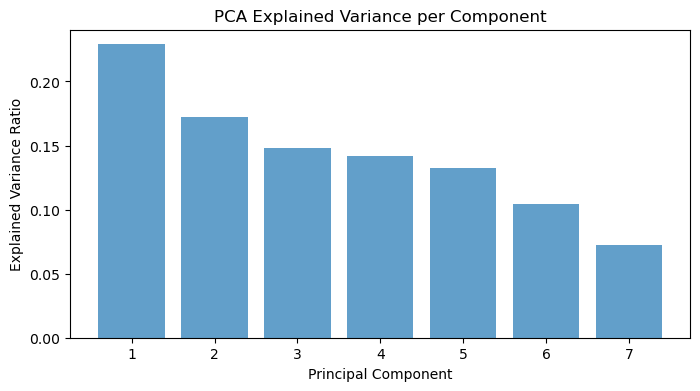

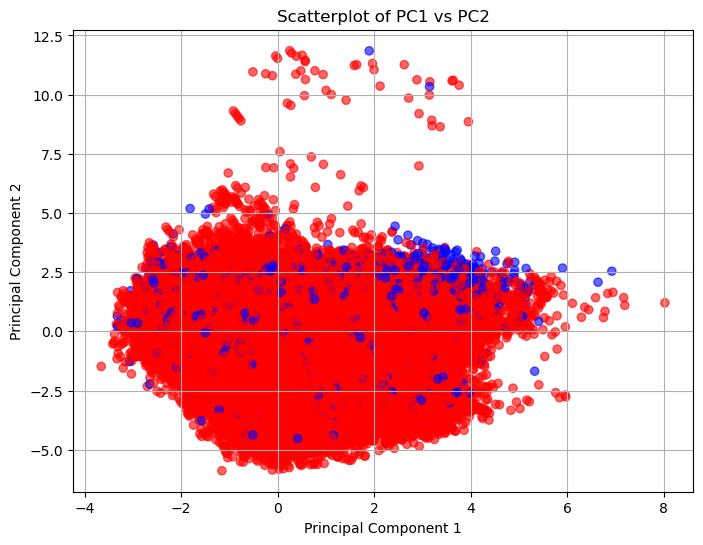

In [5]:
#Cummulative explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()
print(pca.n_components_)


# Correlation Matrix
corr_matrix = numerical.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


# PCA explained per component
plt.figure(figsize=(8,4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance per Component')
plt.show()


# colour coded 0 = red 1 = blue PC plot PC1 vs PC2
claim_column = df['ClaimNb']  
colors = np.where(claim_column == 0, 'red', 'blue')
plt.figure(figsize=(8,6))
plt.scatter( PC.iloc[:, 0],PC.iloc[:, 1],alpha=0.6, c = colors)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatterplot of PC1 vs PC2')
plt.grid(True)
plt.show()


### K-Means and Silhouette Scores

For k = 2, Silhouette Score = 0.214
For k = 3, Silhouette Score = 0.233
For k = 4, Silhouette Score = 0.208
For k = 5, Silhouette Score = 0.196
For k = 6, Silhouette Score = 0.204


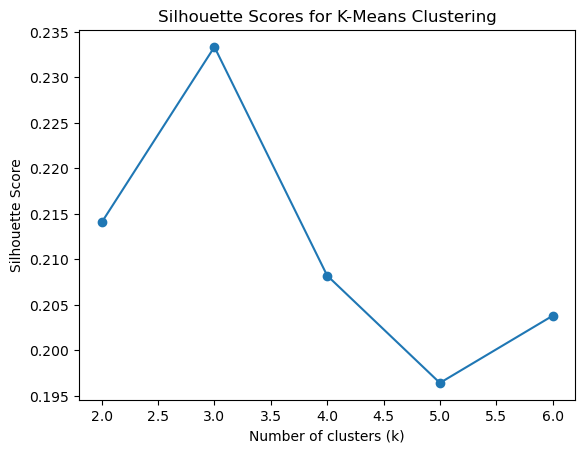

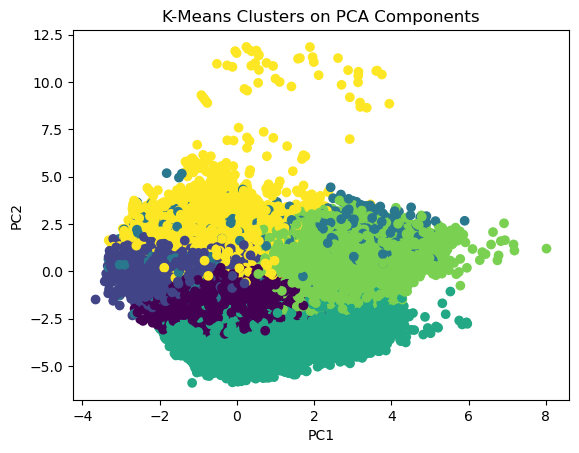

In [6]:

k_values = [2, 3, 4, 5, 6]
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(PC)
    score = silhouette_score(PC, labels)
    silhouette_scores.append(score)
    print(f'For k = {k}, Silhouette Score = {score:.3f}')


# Plotting the silhouette scores for easy comparison
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means Clustering')
plt.show()


# Visualize clusters
plt.scatter(PC['pca_1'], PC['pca_2'], c=labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA Components')
plt.show()